In [1]:
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris()
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
from matplotlib import pyplot as plt

In [2]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [3]:
x,y=iris.data,iris.target
y.shape

(150,)

In [4]:
df = pd.DataFrame(x,columns=iris.feature_names)

In [5]:
df.shape

(150, 4)

In [6]:
df["target"] = iris.target

In [7]:
df["name"] = df.target.apply(lambda x : iris.target_names[x])

In [8]:
df1 = df[["petal length (cm)","petal width (cm)"]]

In [9]:
y_pred = km.fit_predict(df1)
print(y_pred)
df1["cluster"] = y_pred
df1.head(3)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 2 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 2 0 0 2 2 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0
 0 0]


,petal length (cm),petal width (cm),cluster
0,1.4,0.2,1
1,1.4,0.2,1
2,1.3,0.2,1


In [12]:
df1.cluster.unique()
d1 = df1[df1.cluster == 0]
d2 = df1[df1.cluster == 1]
d3 = df1[df1.cluster == 2]

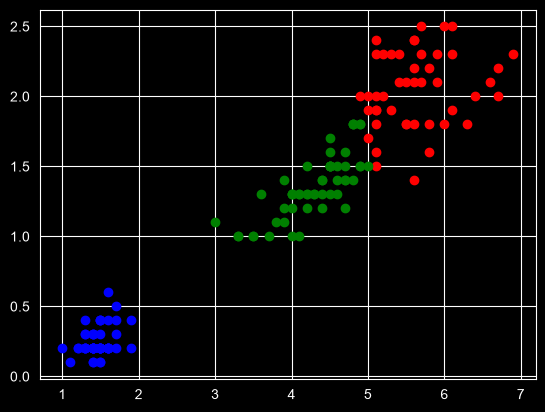

In [15]:
plt.scatter(d1["petal length (cm)"],d1[["petal width (cm)"]],c="red")
plt.scatter(d2["petal length (cm)"],d2[["petal width (cm)"]],c="blue")
plt.scatter(d3["petal length (cm)"],d3[["petal width (cm)"]],c="green")


In [37]:
sse = []

for i in range(1,10):
    km = KMeans(n_clusters=i)
    km.fit(df1[["petal length (cm)","petal width (cm)"]])
    sse.append(km.inertia_)

In [38]:
sse

[550.8953333333334,
 86.39021984551395,
 31.412885668276978,
 19.52973359288098,
 13.91690875790876,
 11.03633387775173,
 10.32984820472933,
 8.70895238095238,
 8.22155699593812]

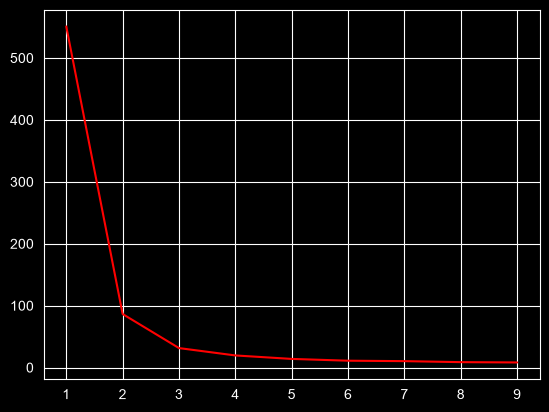

In [39]:
plt.plot(range(1,10),sse,c="red")

In [48]:
mm = MinMaxScaler()

In [50]:
mm.fit(df1[["petal length (cm)","petal width (cm)"]])

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [51]:
df1[["petal length (cm)","petal width (cm)"]] = mm.transform(df1[["petal length (cm)","petal width (cm)"]])

In [52]:
df1

,petal length (cm),petal width (cm),cluster
0,0.067797,0.041667,1
1,0.067797,0.041667,1
2,0.050847,0.041667,1
3,0.084746,0.041667,1
4,0.067797,0.041667,1
...,...,...,...
145,0.711864,0.916667,0
146,0.677966,0.750000,0
147,0.711864,0.791667,0
148,0.745763,0.916667,0


In [53]:
sse = []
ra = range(1,10)
for i in ra:
    km = KMeans(n_clusters=i)
    km.fit(df1[["petal length (cm)","petal width (cm)"]])
    sse.append(km.inertia_)

In [54]:
sse

[28.368353219727194,
 5.176463590044368,
 1.7018746881920963,
 1.1588792731667124,
 0.8611260068770744,
 0.6889019224531716,
 0.5658013138564928,
 0.5536840639147507,
 0.459388937656966]

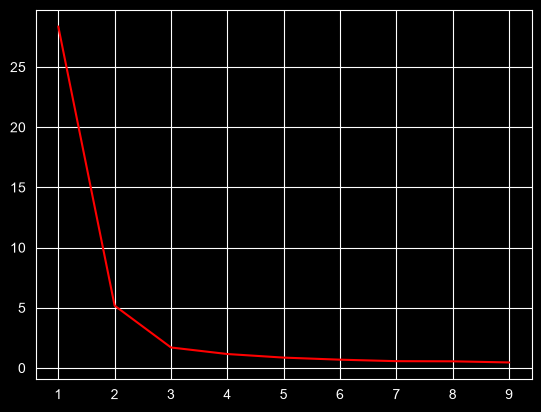

In [55]:
plt.plot(range(1,10),sse,c="red")